In [ ]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, qS, phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

# data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
# print(f'SNR (time-max): {data_snr:.4f}')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, qS_i, phiS_i = params[i]
        try:
            log_likes[i] = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            pass
    return log_likes


def prior_transform(u):
    logm1lim = [5.6,  6.4]
    logm2lim = [1.7, 2.3]
    alim = [0.3, 0.99]
    p0lim = [13.5, 16.5]
    e0lim = [0.6, 0.9]
    qSlim = [0.0, np.pi]
    phiSlim = [0.0, 2 * np.pi]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6,  6.4]
    logm2lim = [1.7, 2.3]
    alim = [0.3, 0.99]
    p0lim = [13.5, 16.5]
    e0lim = [0.6, 0.9]
    qSlim = [0.0, np.pi]
    phiSlim = [0.0, 2 * np.pi]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u


Using dt=5s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage1_again/'
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [3]:
sampler.now_covariances

[array([[ 6.01561615e-04,  4.34648306e-04,  1.78417217e-03,
         -2.50981554e-03, -2.72170676e-04,  3.05670035e-05,
          2.02385979e-04],
        [ 4.34648306e-04,  7.32548312e-04,  7.15394685e-04,
         -9.68808483e-04, -3.54803797e-04, -2.58350530e-04,
          2.58044035e-04],
        [ 1.78417217e-03,  7.15394685e-04,  6.08203518e-03,
         -8.60150917e-03, -5.88943823e-04,  3.80686797e-04,
          4.29112735e-04],
        [-2.50981554e-03, -9.68808483e-04, -8.60150917e-03,
          1.22758335e-02,  8.77984440e-04, -7.37352334e-04,
         -3.60385387e-04],
        [-2.72170676e-04, -3.54803797e-04, -5.88943823e-04,
          8.77984440e-04,  2.21485324e-04,  1.89697517e-05,
          1.89440652e-05],
        [ 3.05670035e-05, -2.58350530e-04,  3.80686797e-04,
         -7.37352334e-04,  1.89697517e-05,  2.21923719e-02,
          2.72659210e-04],
        [ 2.02385979e-04,  2.58044035e-04,  4.29112735e-04,
         -3.60385387e-04,  1.89440652e-05,  2.72659210e-04

In [4]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.83098287,  1.99866379,  0.50439036, 15.70515014,  0.7438042 ,
         1.73721063,  1.32380263]])

In [5]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 5.81342574,  1.9620277 ,  0.50252551, 15.6869839 ,  0.75056173,
         2.76855091,  6.08566719]])

In [6]:
log_density([param_true])

array([-inf])

In [7]:
param_ranges = [(5.6,6.4),
                (1.7,2.3),
                (0.3,0.99),
                (13.5,16.5),
                (0.6,0.9),
                (0.0, np.pi),
                (0.0, 2 * np.pi)
                ]
param_ranges

[(5.6, 6.4),
 (1.7, 2.3),
 (0.3, 0.99),
 (13.5, 16.5),
 (0.6, 0.9),
 (0.0, 3.141592653589793),
 (0.0, 6.283185307179586)]

In [8]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,qS,phiS]
param_true

[5.827369273053825, 1.9929950984313416, 0.5, 15.7117, 0.744, 0.5906, 3.5808]

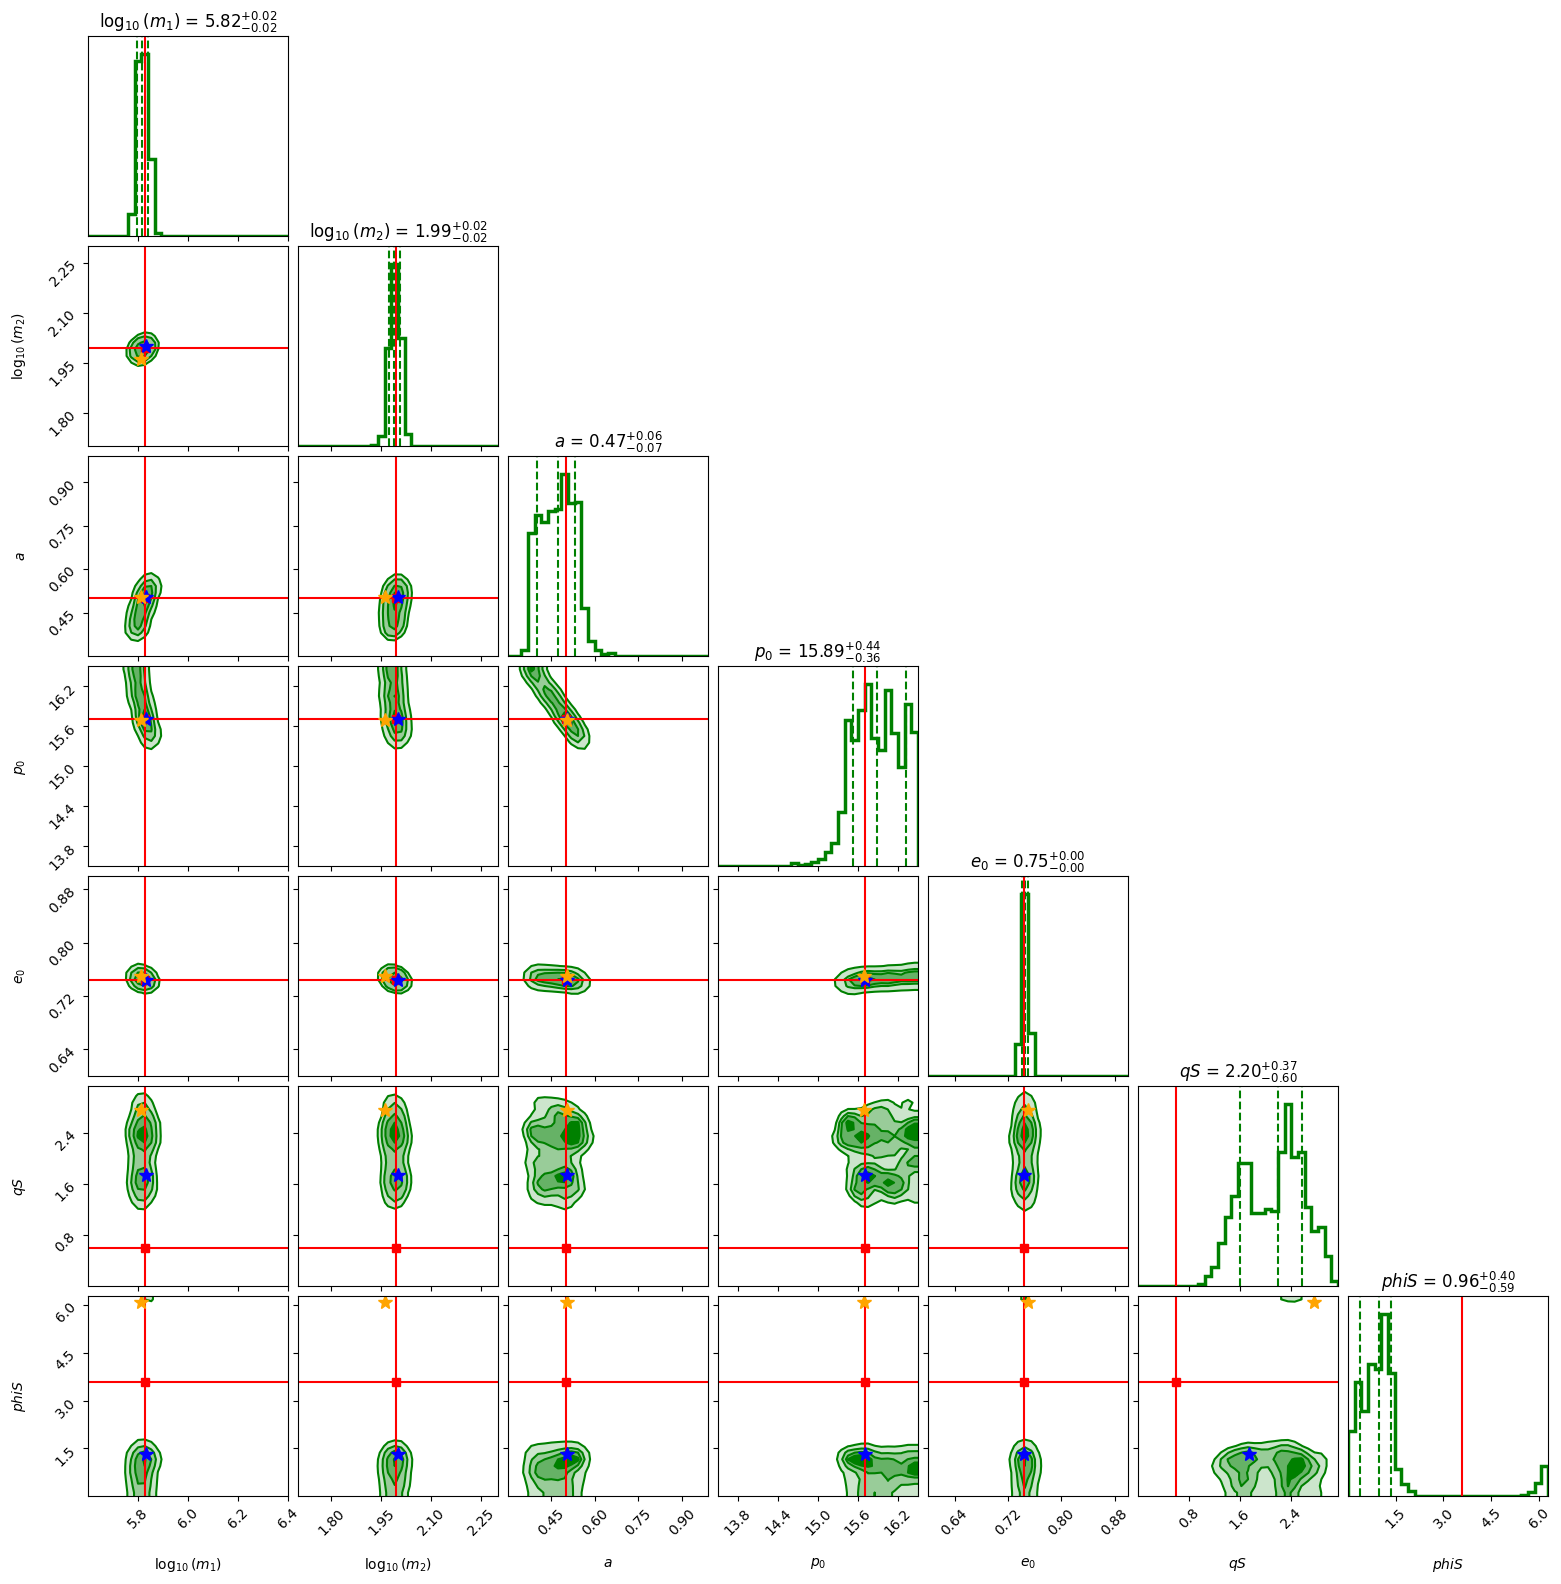

In [9]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$qS$', r'$phiS$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='orange', marker='*', ms=10, 
                       reverse=False)





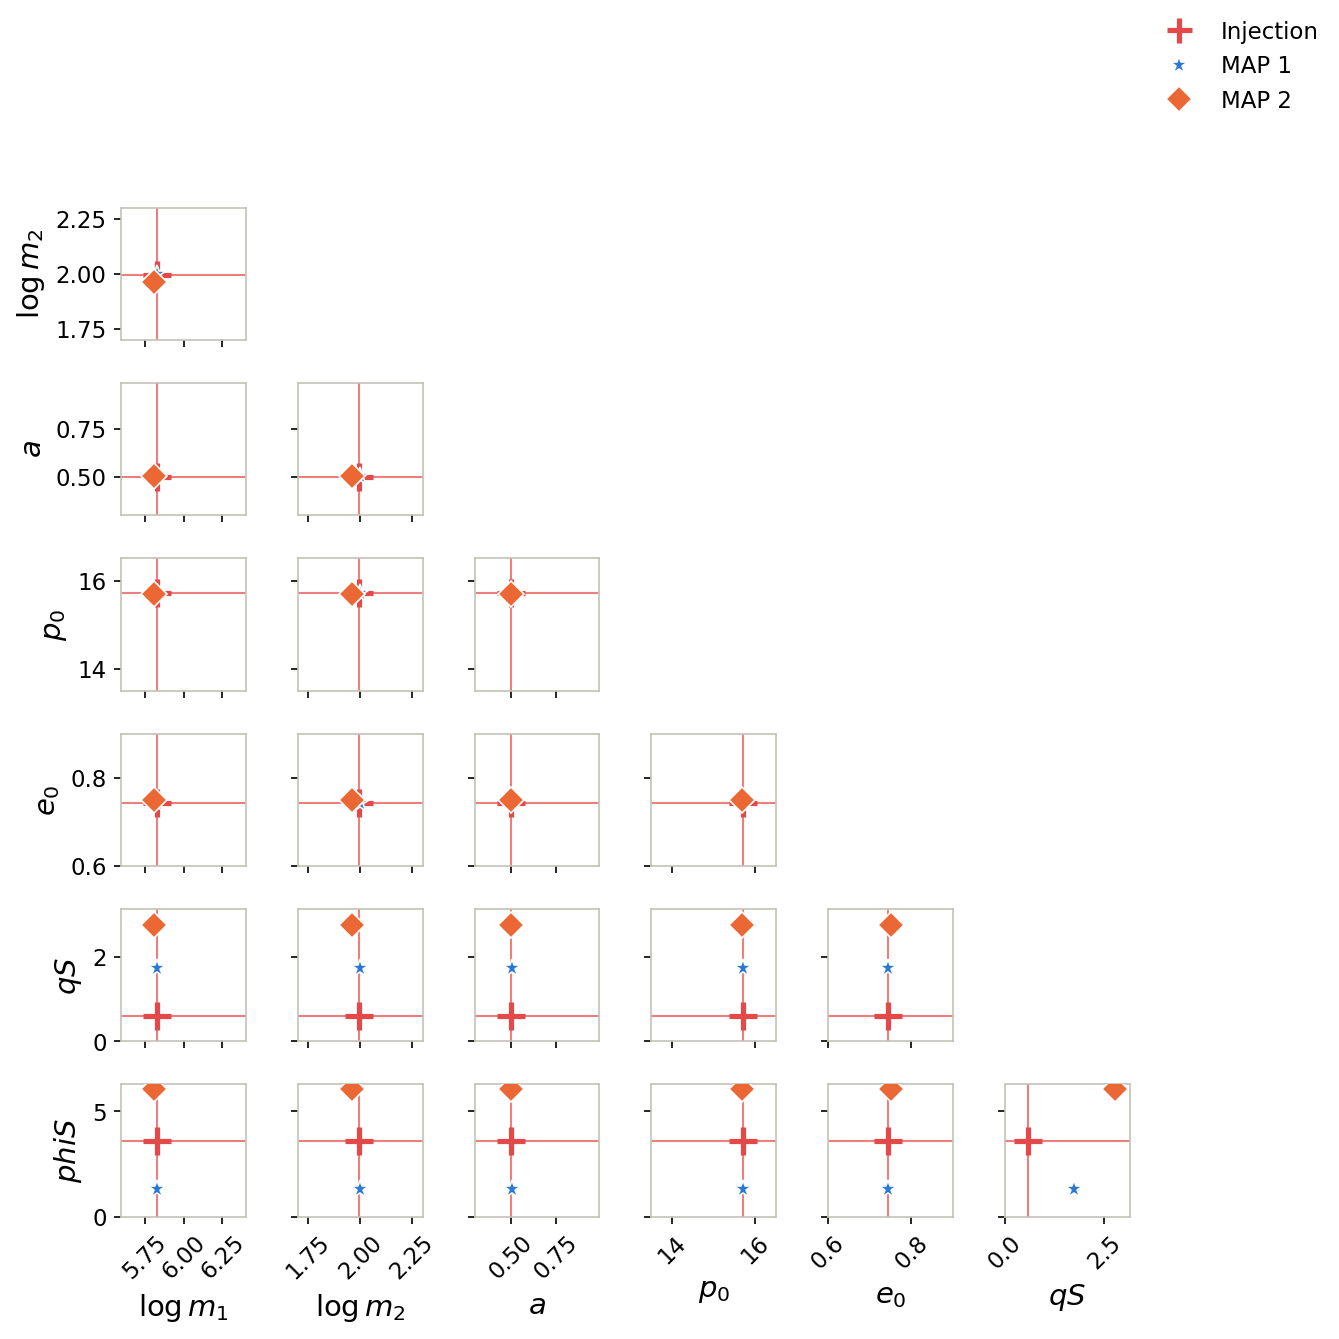

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()

recovered_points = {
    'MAP 1': np.asarray(maxld_pt1).ravel(),
    'MAP 2': np.asarray(maxld_pt2).ravel(),

}

POINT_STYLE = [
    dict(color='#2a78d6', marker='*'),
    dict(color='#eb6834', marker='D'),
    dict(color='#1baf7a', marker='s'),
    dict(color='#4a3aa7', marker='^'),
    dict(color='#e3c30b', marker='o')

]
point_styles = {name: {**POINT_STYLE[i % len(POINT_STYLE)]} for i, name in enumerate(recovered_points)}

param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        #ax.grid(True, color='#e1e0d9', linewidth=0.6, zorder=0)
        for spine in ax.spines.values():
            spine.set_color('#c3c2b7')

        ax.axvline(param_true[j], color='#e34948', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='#e34948', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='#e34948', ms=13, mew=2.5, zorder=2)

        for name, pt in recovered_points.items():
            style = point_styles[name]
            ax.plot(pt[j], pt[i], style['marker'], color=style['color'], ms=9, mew=0.8, mec='white', zorder=5)

        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [Line2D([0], [0], color='#e34948', marker='+', ls='', ms=12, mew=2.5, label='Injection')]
for name, style in point_styles.items():
    handles.append(Line2D([0], [0], color=style['color'], marker=style['marker'], ls='', ms=9, mec='white', mew=0.8, label=name))

fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=11)
fig.tight_layout()

In [ ]:

import numpy as np
import few
import os
import sys

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5

m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

n_vals = np.arange(-1, 6)
ell = 2

T_values = [3/12, 6/12, 9/12, 1.0]

print(f'{"T (yr)":>8} {"rho_tot":>10} {"rho_dom_M":>10} {"alpha":>8} {"beta":>10} {"logl":>12}')
for T in T_values:
    print(f'Building for T={T}...')
    waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
    gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

    loglike_obj = LogLike(
        params=params_star,
        waveform_response=waveform_response,
        gwf=gwf,
        add_noise=True,
        seed=42,
        verbose=False,
        ell=ell,
        n_vals=n_vals,
        M_mode=None,
    )

    theta_template = params_star
    selected = loglike_obj.selected_labels
    waveform_combined = loglike_obj._generate_selected_waveforms(theta_template, selected)

    h_temp = gwf.xp.array(waveform_response(*theta_template, T=T, dt=dt))
    h_temp_fft = gwf.wave_fft(h_temp)
    mode_ffts = [gwf.wave_fft(waveform_combined[i]) for i in range(waveform_combined.shape[0])]

    rho_tot = gwf.xp.sqrt(gwf.inner_timemax_f(h_temp_fft, h_temp_fft))
    rho_m = gwf.xp.array([gwf.xp.sqrt(gwf.inner_timemax_f(hf, hf)) for hf in mode_ffts])
    max_idx = int(rho_m.argmax())
    alpha = float(rho_m[max_idx] / rho_tot)
    beta = float(gwf.calc_beta(rho_m[max_idx], rho_tot))

    logl = loglike_obj(theta_template)

    rho_tot_f = float(rho_tot)
    rho_dom_f = float(rho_m[max_idx])
    print(f'{T:8.4f} {rho_tot_f:10.4f} {rho_dom_f:10.4f} {alpha:8.4f} {beta:10.4f} {logl:12.4f}')
    print(f'  all mode rho: {[float(r) for r in rho_m]}')
    print(f'  n_modes in dominant group: {len(loglike_obj.flattened_modes)}, groups: {len(selected)}')

print('Done.')


  T (yr)    rho_tot  rho_dom_M    alpha       beta         logl
Building for T=0.25...
  0.2500    44.8377     0.3362   0.0075    -0.0011         -inf
  all mode rho: [0.08735774188433824, 0.33616324173683426, 0.1999707226802217, 0.01899472671023604, 0.03486773576245017, 0.05215995063698075, 0.07048117078926677]
  n_modes in dominant group: 35, groups: 7
Building for T=0.5...
  0.5000    53.5438     0.4314   0.0081    -0.0006         -inf
  all mode rho: [0.4161139057413023, 0.43136413657492745, 0.3183986209400732, 0.029768772574942738, 0.05276865583870307, 0.07678550144319057, 0.10046840461575679]
  n_modes in dominant group: 35, groups: 7
Building for T=0.75...
  0.7500    61.1883     2.1240   0.0347     0.0004      62.9719
  all mode rho: [2.123952464704162, 0.46556285103444145, 0.6869551008463427, 0.06467254411595148, 0.10041583779345459, 0.13011594540207397, 0.15174847760236884]
  n_modes in dominant group: 35, groups: 7
Building for T=1.0...
